### Bu defterde makine öğrenmesinde matematik ve cebirin rolünü öğrenmek için hazır kodlar yerine tek değişken için normal denklemi üzerinden diyabet tahmini yapmaya çalıştım

## Veriyi Yükleme ve Hazırlama

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [16]:
diabets = load_diabetes() # veri setinin yüklenmesi

# X: sadece 'bmi' özelliğini alır ve 2D matris yapar
X = diabets.data[:, np.newaxis, 2]
# y: hedef değişkeni alır
y = diabets.target

In [17]:
print("X shape:\n", X.shape, "\n") # Bmi özelliğinin boyutu
print("y shape:\n", y.shape) #hedef değişkenin boyutu

X shape:
 (442, 1) 

y shape:
 (442,)


## X Matrisini Hazırlanması

matrisimiz ve modelimiz uyuşmadığından matrisi modele uygun hale getirmemiz gerekiyor bunu ise 

$y_1 = \beta_1 \cdot \text{bmi}_1$
$y_2 = \beta_1 \cdot \text{bmi}_2$

denklemini

$y = \beta_1 x_1 + \beta_0$ 

gibi bir doğru haline getirerek çözeriz  verinin orjinde olmadığını biliyoruz bu yüzden $\beta_0$ kaydırıp veriye odaklı bir hale getiririz kısaca bias terimi için "1'ler sütunu" eklememiz gerekir  Bu sayede matris denklemimiz, Lineer Cebir'in çözmesi için $\beta_0$'ı da içeren doğru modele (geometriye) dönüşmüş olur

In [18]:
X_b = np.c_[np.ones((X.shape[0], 1)), X]

print("Yeni X_b matrisinin boyutu:", X_b.shape)

Yeni X_b matrisinin boyutu: (442, 2)


## Normal Denkleminin Uygulanması (Lineer Cebir Motoru)

Bu, $\beta = (X^\top X)^{-1} X^\top y$ olarak bilinen "Normal Denklem" formülünün saf numpy ile uygulanmasıdır.

In [ ]:
beta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) # normal denklem çözümü

print("Hesaplanan beta katsayilari:\n", beta)
print("İntercept (beta_0):\n", beta[0])
print("BMİ katsayısı (beta_1):\n", beta[1])

Hesaplanan beta katsayilari:
 [152.13348416 949.43526038]
İntercept (beta_0):
 152.13348416289622
BMİ katsayısı (beta_1):
 949.4352603840385


denklem önce matrisin transpozunu alır sonra kendisiyle çarpıp bias ve BMI nin birbiri ile ilişkisi olan bir matris oluşturur sonra bu matrisin tersini alıp hedef değişken olan y ile olan ilişkisi ile çarpar

$y = \beta_0 + \beta_1 x$

modelin baseline değeri ($\beta_0$ Intercept) = 152.13348416

modelin eğimi ($\beta_1$ Eğim)  = 949.43526038

baseline değerimiz bize doğrumuzun nereden başlaması gerektiğini gösterir yani verinin ortasına kaydırılır
eğim değerimiz ise BMİ ile diyabet arasındaki ilişkiyi açıklamamızı sağlar BMİ deki her 1 birimlik artış için diyabet skorunda ne kadar artış olduğunu görürüz

In [ ]:
y_pred = X_b.dot(beta) # Eğitilmiş beta katsayılarını (intercept ve eğim) kullanarak tahminleri (y_pred) hesaplamak

## Görselleştirme ve Analiz

- tahminimizin verinin ortasına konumlandığını görebiliyoruz normal denklem formülümüzün noktalar ile çizgi arasındaki toplam hatayı minimize eden optimal çözümü başarılı bir şekilde buldu 

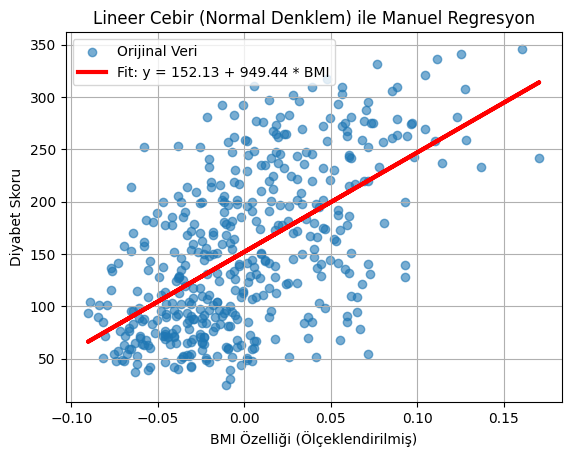

In [21]:
plt.scatter(X, y, alpha=0.6, label='Orijinal Veri')

plt.plot(X, y_pred, color='red', linewidth=3, label=f'Fit: y = {beta[0]:.2f} + {beta[1]:.2f} * BMI')
plt.title('Lineer Cebir (Normal Denklem) ile Manuel Regresyon')
plt.xlabel('BMI Özelliği (Ölçeklendirilmiş)')
plt.ylabel('Diyabet Skoru')
plt.legend()
plt.grid(True)
plt.show()